In [2]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests and plots
from statsmodels.api import qqplot
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Machine learning imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Carregamento do dataset de doenças cardíacas
heart_data = pd.read_csv('../data/raw/train.csv')
print(f"Número total de registros: {len(heart_data)}")
print(f"Dimensões do dataset: {heart_data.shape}")
print("\nPrimeiras 5 linhas do dataset:")
heart_data.head()

Número total de registros: 630000
Dimensões do dataset: (630000, 15)

Primeiras 5 linhas do dataset:


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
# Examine a estrutura do dataset: tipos de dados, valores não nulos, uso de memória
print("Informações gerais do dataset:")
print("=" * 40)
heart_data.info()

Informações gerais do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-nul

In [5]:
# Definição das variáveis categóricas e numéricas
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                       'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 
                       'Thallium', 'Heart Disease']

numeric_features = [col for col in heart_data.columns 
                   if col not in categorical_features and col != 'id']

print(f"Variáveis categóricas ({len(categorical_features)}): {categorical_features}")
print(f"Variáveis numéricas ({len(numeric_features)}): {numeric_features}")

Variáveis categóricas (9): ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
Variáveis numéricas (5): ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']


In [6]:
# Estatísticas descritivas para as variáveis numéricas
print("Estatísticas descritivas das variáveis numéricas:")
print("=" * 50)
heart_data[numeric_features].describe().round(2)

Estatísticas descritivas das variáveis numéricas:


,Age,BP,Cholesterol,Max HR,ST depression
count,630000.00,630000.00,630000.00,630000.00,630000.00
mean,54.14,130.50,245.01,152.82,0.72
std,8.26,14.98,33.68,19.11,0.95
min,29.00,94.00,126.00,71.00,0.00
25%,48.00,120.00,223.00,142.00,0.00
50%,54.00,130.00,243.00,157.00,0.10
75%,60.00,140.00,269.00,166.00,1.40
max,77.00,200.00,564.00,202.00,6.20


In [7]:
# Verificação de valores ausentes
missing = heart_data.isna().sum()
print("Valores ausentes por variável:")
print("=" * 30)
print(missing[missing > 0] if missing.sum() > 0 else "✓ Nenhum valor ausente encontrado!")

Valores ausentes por variável:
✓ Nenhum valor ausente encontrado!


In [8]:
# Verificação de registros duplicados
duplicates = heart_data.duplicated().sum()
print(f"Registros duplicados: {duplicates}")
if duplicates == 0:
    print("✓ Nenhum registro duplicado encontrado!")
else:
    print(f"⚠️  Encontrados {duplicates} registros duplicados")

Registros duplicados: 0
✓ Nenhum registro duplicado encontrado!


In [9]:
# Transformação das variáveis categóricas binárias em rótulos descritivos
transformations = {
    'Sex': {1: 'male', 0: 'female'},
    'FBS over 120': {1: 'true', 0: 'false'},
    'Exercise angina': {1: 'yes', 0: 'no'}
}

for feature, mapping in transformations.items():
    heart_data[feature] = heart_data[feature].map(mapping)
    print(f"✓ {feature}: {mapping}")

print("\nDistribuição após transformação:")
for feature in transformations.keys():
    print(f"{feature}: {heart_data[feature].value_counts().to_dict()}")

✓ Sex: {1: 'male', 0: 'female'}
✓ FBS over 120: {1: 'true', 0: 'false'}
✓ Exercise angina: {1: 'yes', 0: 'no'}

Distribuição após transformação:
Sex: {'male': 450283, 'female': 179717}
FBS over 120: {'false': 579608, 'true': 50392}
Exercise angina: {'no': 457553, 'yes': 172447}


In [10]:
# Conversão das variáveis categóricas para o tipo 'category' para otimização de memória
print("Convertendo variáveis categóricas para tipo 'category':")
for feature in categorical_features:
    heart_data[feature] = heart_data[feature].astype('category')
    print(f"✓ {feature}")

# Remove 'Heart Disease' da lista de features para análise (é nossa variável target)
categorical_features = categorical_features[:-1]

print(f"\nFeatures categóricas para análise: {categorical_features}")
print(f"Variável target: Heart Disease")

Convertendo variáveis categóricas para tipo 'category':
✓ Sex
✓ Chest pain type
✓ FBS over 120
✓ EKG results
✓ Exercise angina
✓ Slope of ST
✓ Number of vessels fluro
✓ Thallium
✓ Heart Disease

Features categóricas para análise: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Variável target: Heart Disease


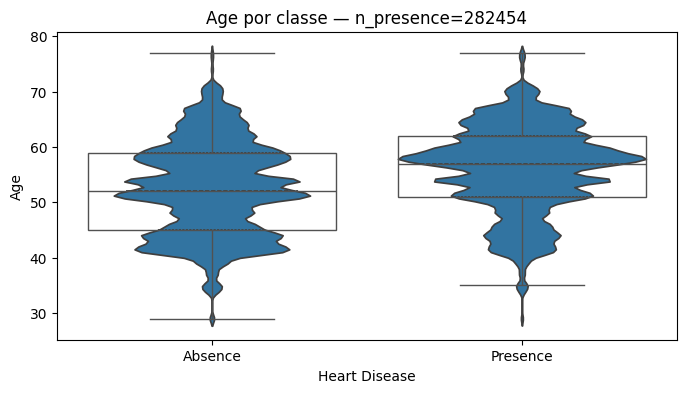

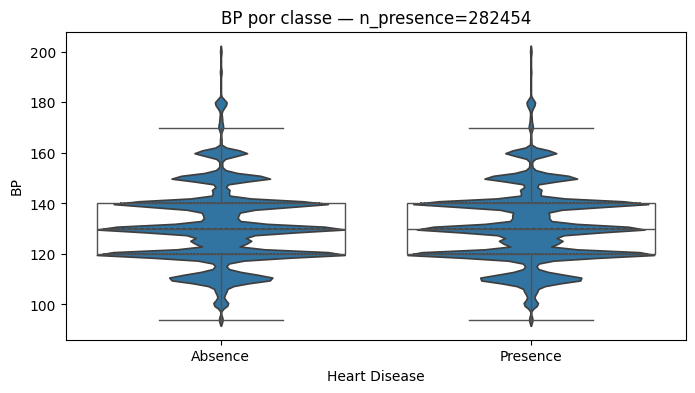

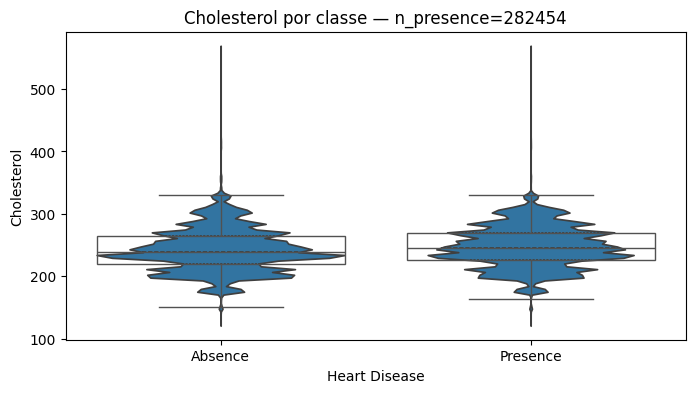

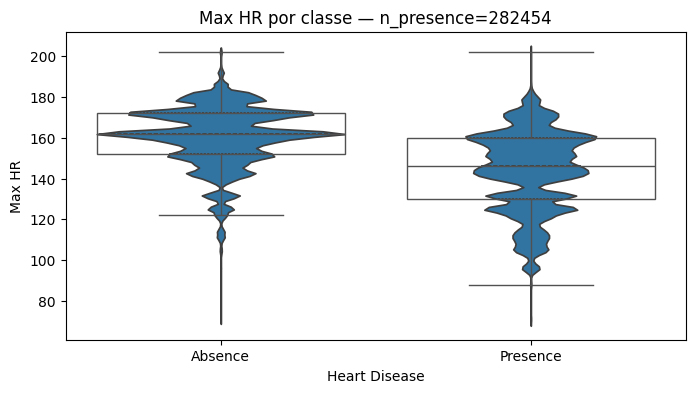

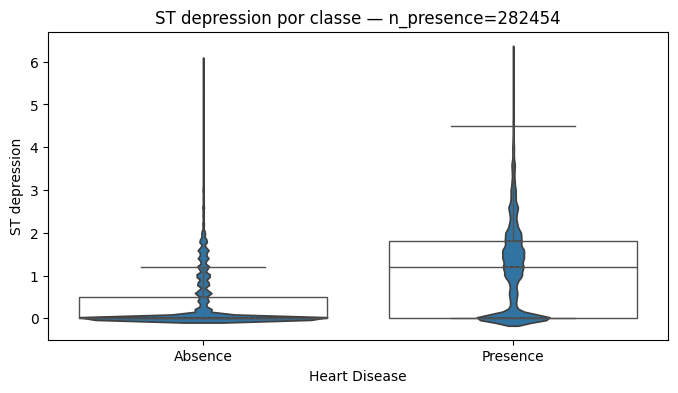

In [11]:
# Visualize the distribution of numeric features
for feature in numeric_features:
    plt.figure(figsize=(8,4))
    sns.violinplot(x='Heart Disease', y=feature, data=heart_data, inner='quartile')
    sns.boxplot(x='Heart Disease', y=feature, data=heart_data,
                showcaps=True, boxprops={'facecolor':'none'}, showfliers=False)
    plt.title(f'{feature} por classe — n_presence={heart_data[heart_data["Heart Disease"]=="Presence"].shape[0]}')
    plt.show()

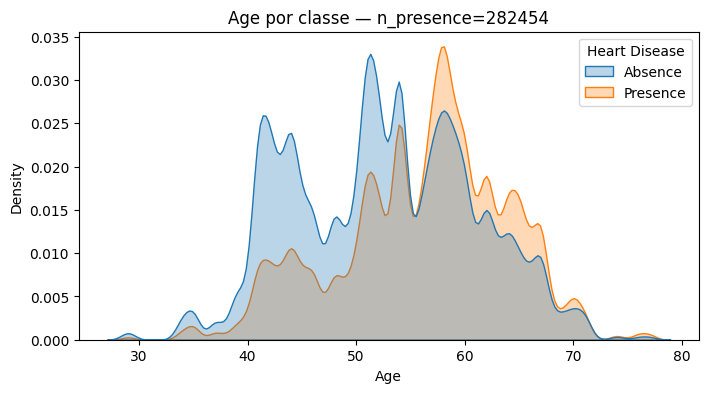

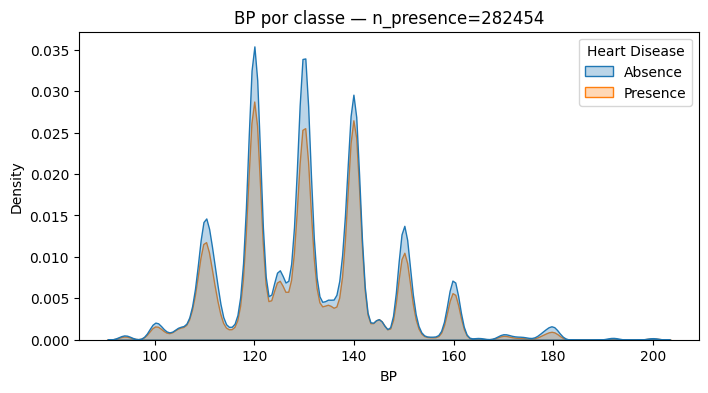

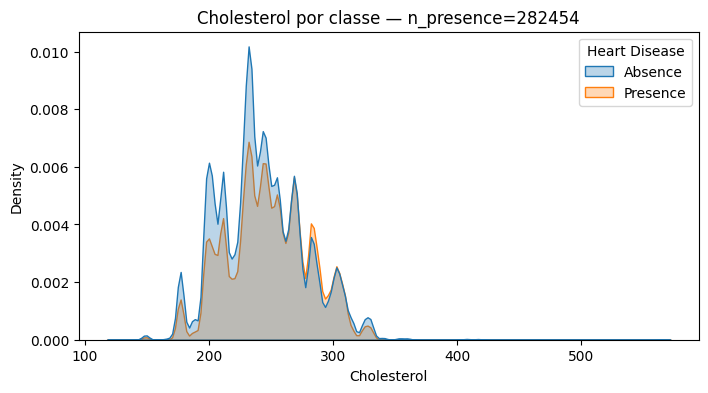

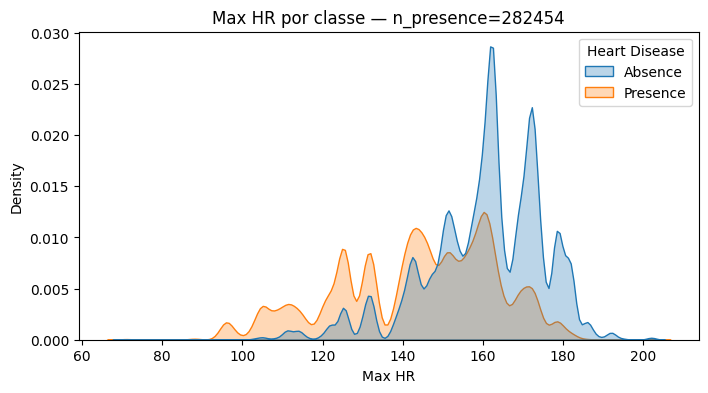

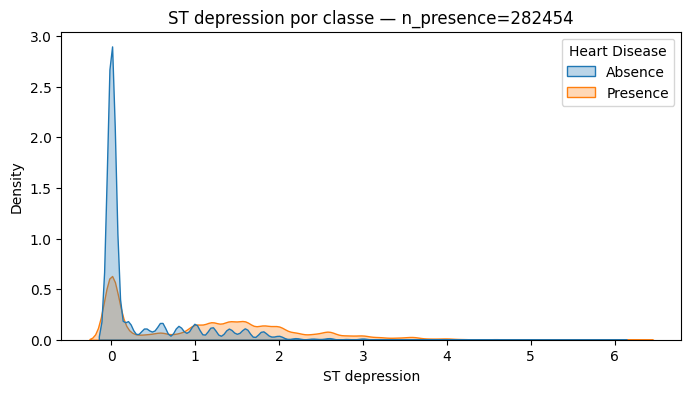

In [12]:
for feature in numeric_features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(
        data=heart_data,
        x=feature,
        hue='Heart Disease',
        fill=True,
        alpha=0.3
    )
    plt.title(f'{feature} por classe — n_presence={heart_data[heart_data["Heart Disease"]=="Presence"].shape[0]}')
    plt.show()

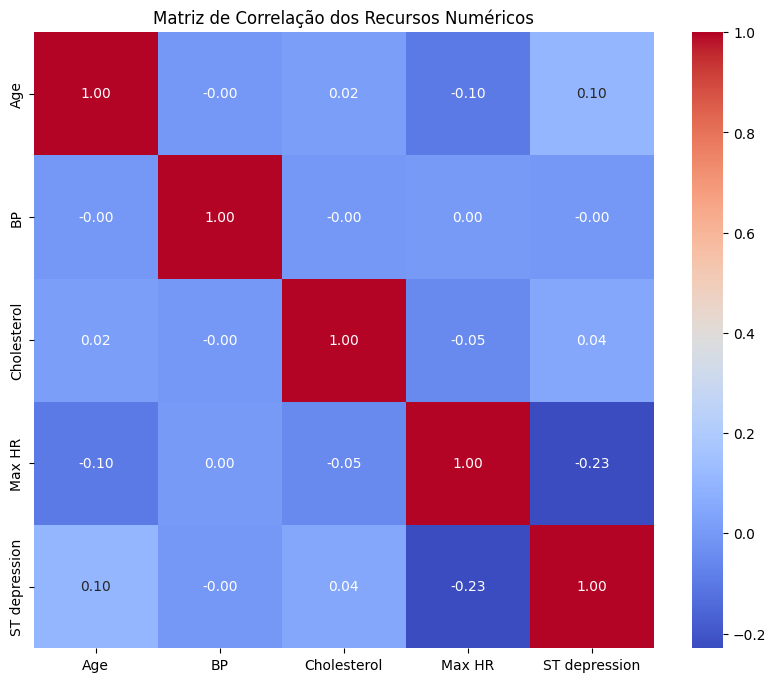

In [13]:
correlation_matrix = heart_data[numeric_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação dos Recursos Numéricos')
plt.show()

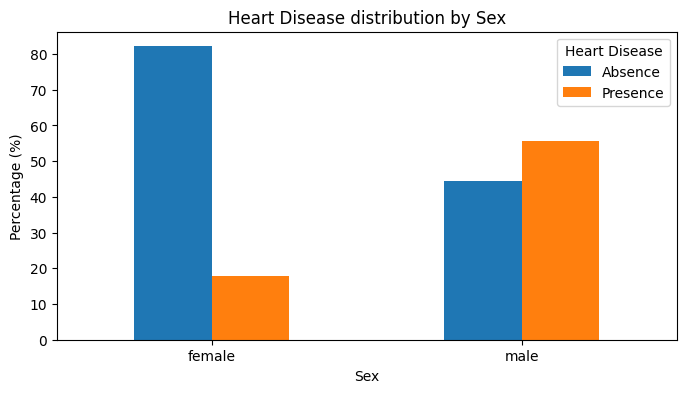

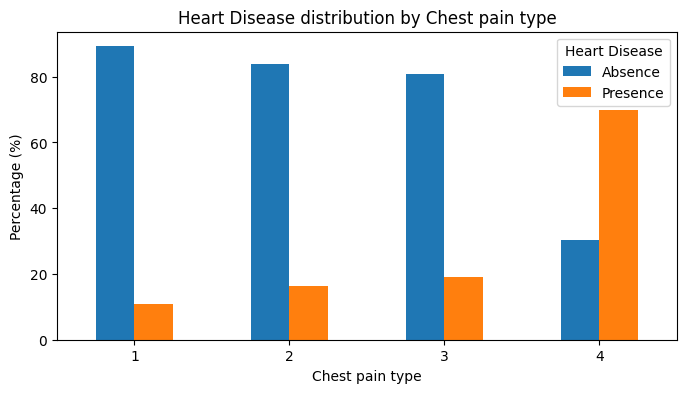

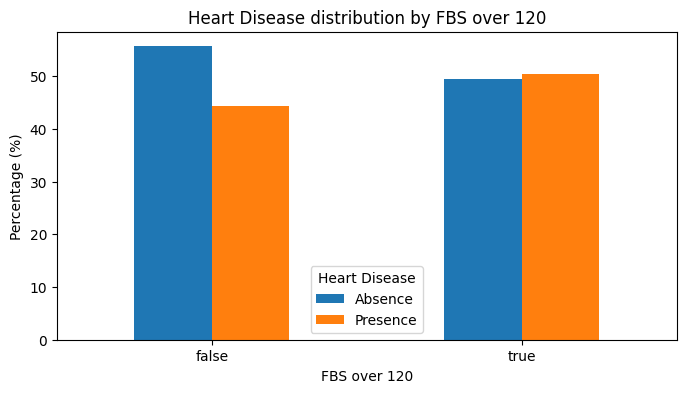

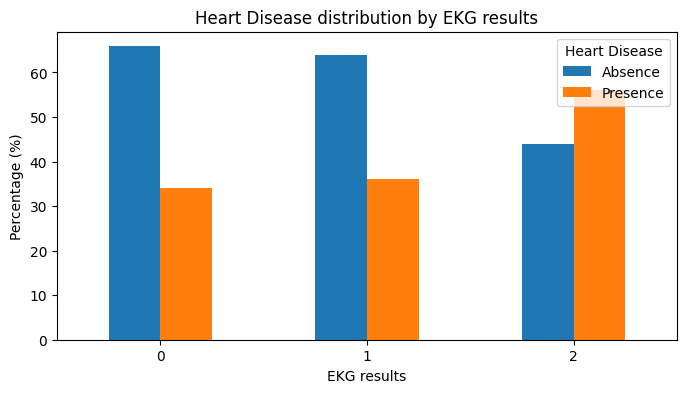

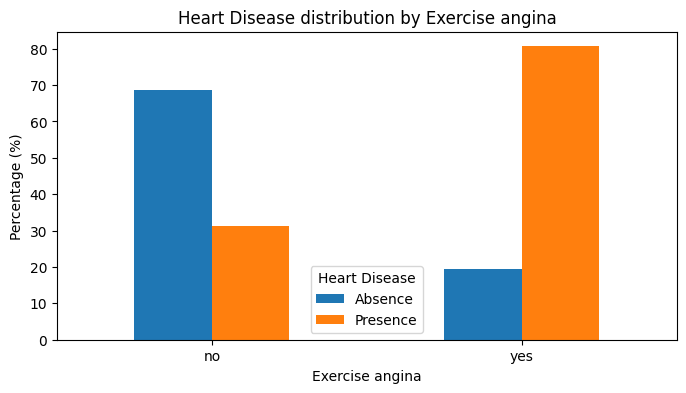

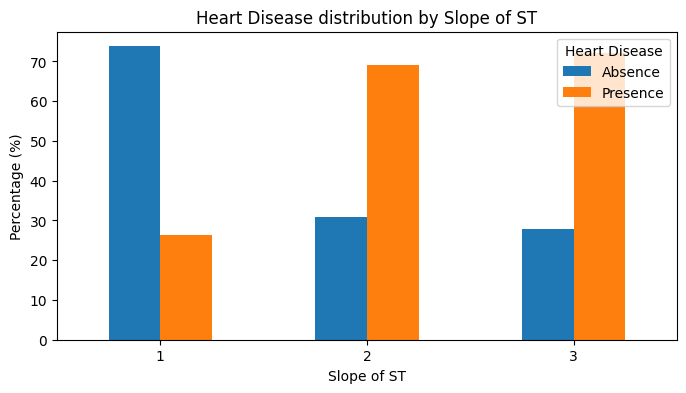

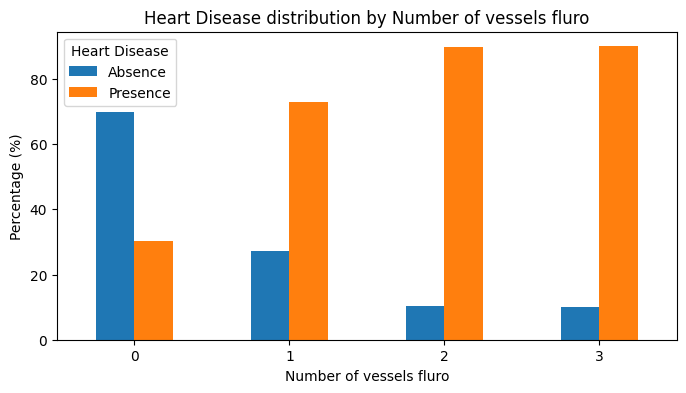

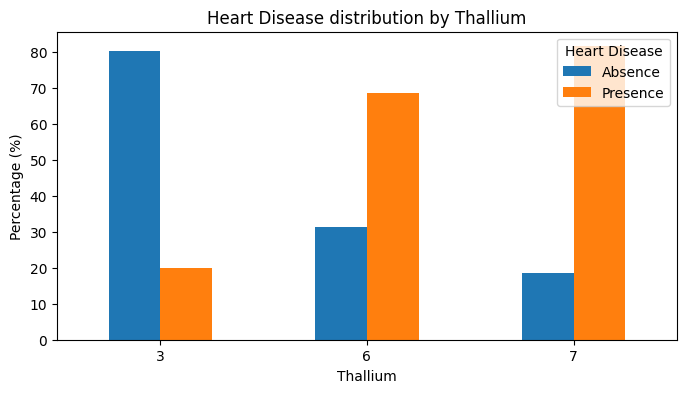

In [14]:
for feature in categorical_features:
    pivot = (
        heart_data
        .groupby(feature)['Heart Disease']
        .value_counts(normalize=True)
        .unstack()
        * 100
    )

    pivot.plot(kind='bar', figsize=(8,4))
    plt.ylabel('Percentage (%)')
    plt.title(f'Heart Disease distribution by {feature}')
    plt.xticks(rotation=0)
    plt.show()

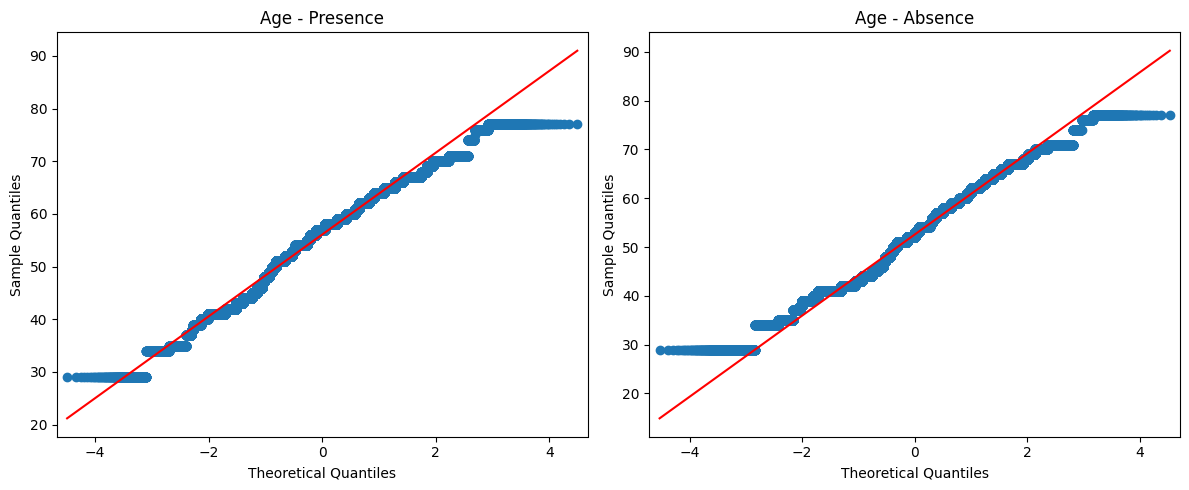

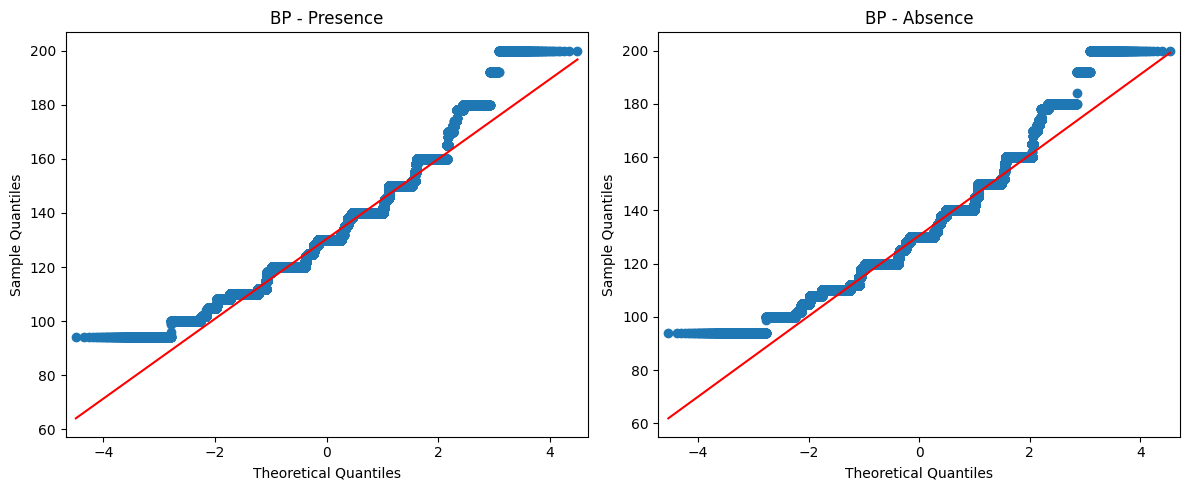

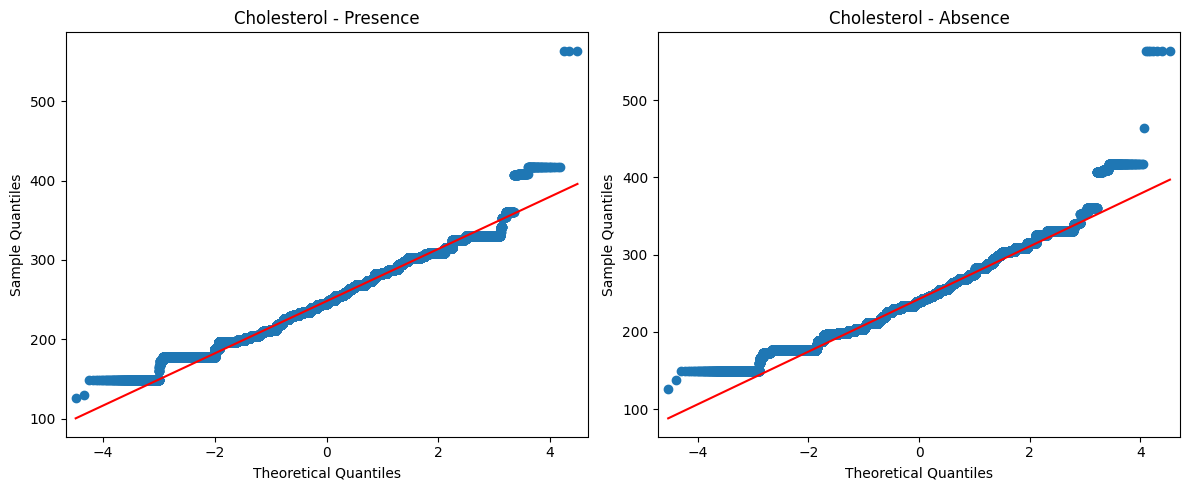

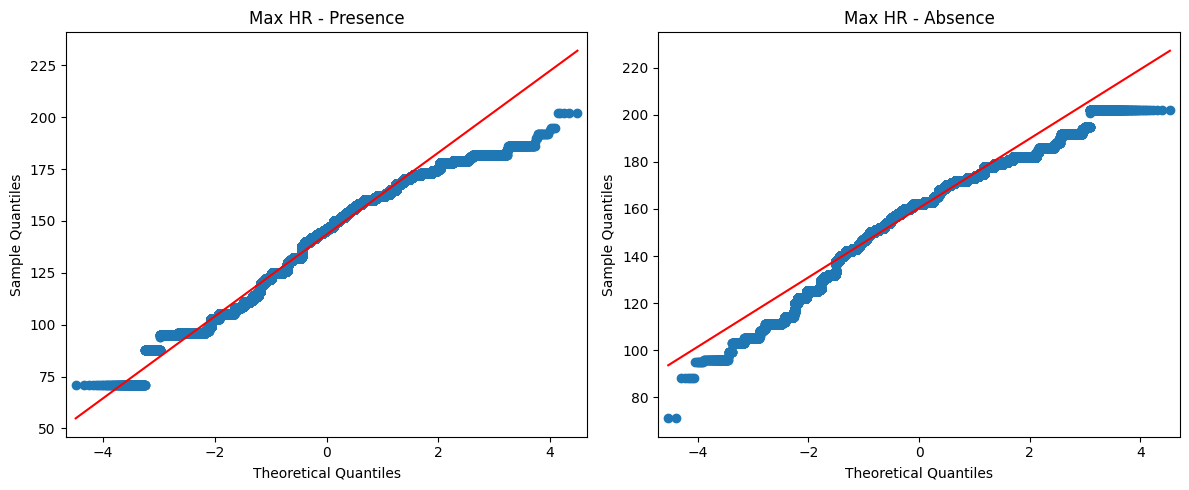

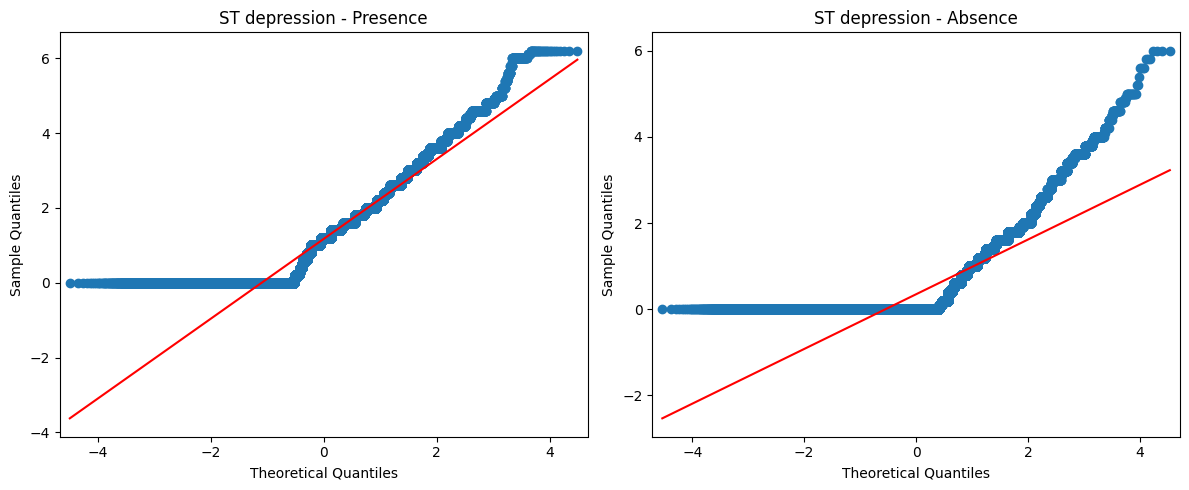

In [15]:
# Check normality of numeric features using QQ plots
for feature in numeric_features:
    
    g1 = heart_data.loc[
        heart_data['Heart Disease'] == 'Presence', feature
    ].dropna()

    g2 = heart_data.loc[
        heart_data['Heart Disease'] == 'Absence', feature
    ].dropna()

    # Create subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # QQ plot Presence
    qqplot(g1, line='s', ax=axes[0])
    axes[0].set_title(f'{feature} - Presence')
    
    # QQ plot Absence
    qqplot(g2, line='s', ax=axes[1])
    axes[1].set_title(f'{feature} - Absence')
    
    plt.tight_layout()
    plt.show()

In [16]:
# Since the numeric features do not appear to be normally distributed,
# we will use the Mann-Whitney U test to compare the distributions between the 'Presence' and 'Absence' groups
# for each feature. The rank-biserial correlation will be calculated to measure the effect size.
def rank_biserial_u(U, n1, n2):
    return 1 - (2 * U) / (n1 * n2)

results = []
for feature in numeric_features:
    # dropna
    g1 = heart_data.loc[heart_data['Heart Disease']=='Presence', feature].dropna()
    g2 = heart_data.loc[heart_data['Heart Disease']=='Absence', feature].dropna()
    n1, n2 = len(g1), len(g2)

    # quick descriptives
    desc = {
        'feature': feature,
        'n_presence': n1,
        'n_absence': n2,
        'median_presence': g1.median(),
        'median_absence': g2.median(),
        'mean_presence': g1.mean(),
        'mean_absence': g2.mean(),
        'iqr_presence': g1.quantile(0.75) - g1.quantile(0.25),
        'iqr_absence': g2.quantile(0.75) - g2.quantile(0.25)
    }

    # Mann-Whitney (two-sided, asymptotic for large n)
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided', method='asymptotic')
    
    # Calculate rank-biserial correlation
    r_rb = rank_biserial_u(stat, n1, n2)

    desc.update({'U': stat, 'p_value': p, 'rank_biserial': r_rb})
    results.append(desc)

res_df = pd.DataFrame(results)

In [17]:
# Correção para múltiplos testes (FDR)
rej, pvals_corrected, _, _ = multipletests(res_df['p_value'], method='fdr_bh')
res_df['p_adj_fdr'] = pvals_corrected
res_df['reject_fdr'] = rej

In [18]:
# Ordenar por p_adj
res_df = res_df.sort_values('p_adj_fdr')
res_df

,feature,n_presence,n_absence,median_presence,median_absence,mean_presence,mean_absence,iqr_presence,iqr_absence,U,p_value,rank_biserial,p_adj_fdr,reject_fdr
0,Age,282454,347546,57.0,52.0,56.079114,52.558093,11.0,14.0,6.141781e+10,0.000000,-0.251308,0.000000,True
2,Cholesterol,282454,347546,246.0,239.0,248.103585,242.499102,43.0,46.0,5.427624e+10,0.000000,-0.105808,0.000000,True
3,Max HR,282454,347546,146.0,162.0,143.467372,160.415105,30.0,20.0,2.396147e+10,0.000000,0.511816,0.000000,True
4,ST depression,282454,347546,1.2,0.0,1.169104,0.347808,1.8,0.5,7.202202e+10,0.000000,-0.467355,0.000000,True
1,BP,282454,347546,130.0,130.0,130.411366,130.567381,20.0,20.0,4.913056e+10,0.503108,-0.000972,0.503108,False


In [19]:
X = heart_data.drop(columns=['id', 'Heart Disease'])
y = heart_data['Heart Disease'].cat.codes

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f'AUC: {auc_score:.4f}')

AUC: 0.9473


In [22]:
feature_importances = {}
for feature, value in zip(X_train.columns, model.feature_importances_):
    feature_importances[feature] = value

feature_importances_df =  pd.DataFrame.from_dict(feature_importances, orient='index', columns=['importance'])
feature_importances_df = feature_importances_df.sort_values('importance', ascending=False)
feature_importances_df

,importance
Thallium_7,0.189255
Max HR,0.137172
Chest pain type_4,0.118021
ST depression,0.090297
Cholesterol,0.087565
Age,0.076778
Exercise angina_yes,0.066672
BP,0.061596
Slope of ST_2,0.044709
Sex_male,0.030239
